# GHG Emission Forecasting for ASEAN Countries

This notebook builds a compact, production-style forecasting workflow for greenhouse gas (GHG) emissions across selected ASEAN countries.

The design goal is practical rather than decorative:
- keep the pipeline readable for Kaggle reviewers,
- keep the code lean by removing unused outputs and redundant structures,
- evaluate each forecast with rolling backtesting,
- generate a configurable multi-year forecast from a single parameter block at the top.


## Notebook structure

1. Define the global configuration.
2. Load and standardize the source tables.
3. Build country-level features with lag selection.
4. Compare several forecasting candidates with rolling backtests.
5. Export two final outputs:
   - `country_model_evaluation.csv`
   - `country_ghg_forecast_<start>_<end>.csv`

This version intentionally avoids extra artifacts such as lag summaries, backtest prediction tables, candidate dumps, and run summaries, because they add noise without helping the final deliverable.


In [1]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/private/tmp")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from scipy.stats import ConstantInputWarning
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
warnings.filterwarnings("ignore", category=ConstantInputWarning)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Core settings. These are the main values to adjust before rerunning the notebook.
COUNTRIES = [
    "Brunei Darussalam",
    "Timor-Leste",
    "Cambodia",
    "Indonesia",
    "Lao PDR",
    "Malaysia",
    "Myanmar",
    "Philippines",
    "Singapore",
    "Thailand",
]

EXOGENOUS_FEATURES = [
    "temperature",
    "energy_consumption",
    "sustainable_energy",
    "forest_area_pct",
    "gdp_per_capita",
]

AUTOREGRESSIVE_LAGS = 5
MAX_EXOGENOUS_LAG = 5
MIN_TRAIN_SIZE = 18
MAX_BACKTEST_YEARS = 6
FORECAST_YEARS = 5
FLOAT_PRECISION = 3

# The notebook first looks for the local folder, then a common Kaggle input folder.
DATA_ROOT_CANDIDATES = [
    Path("data_effect_climate_change"),
    Path("/kaggle/input/data-effect-climate-change"),
]

DATA_ROOT = next((path for path in DATA_ROOT_CANDIDATES if path.exists()), DATA_ROOT_CANDIDATES[0])

SOURCE_FILES = {
    "ghg_current": ("OWID_CB_TOTAL_GHG_WIDEF.ods", "excel"),
    "temperature": ("WB_CCKP_TAS_WIDEF.csv", "csv"),
    "energy_consumption": ("OWID_CB_PRIMARY_ENERGY_CONSUMPTION_WIDEF.csv", "csv"),
    "sustainable_energy": ("WB_SE4ALL_EG_FCON_RNEW_WIDEF.csv", "csv"),
    "forest_area_pct": ("WB_WDI_AG_LND_FRST_ZS_WIDEF.csv", "csv"),
    "gdp_per_capita": ("WB_WDI_NY_GDP_PCAP_KN_WIDEF.csv", "csv"),
}

print(f"Using data root: {DATA_ROOT}")


Using data root: data_effect_climate_change


## Load the source data

The raw files are wide-format country tables. The helper functions below keep the loading logic centralized so the rest of the notebook can stay focused on modeling.


In [2]:
def load_sources(data_root: Path) -> dict[str, pd.DataFrame]:
    """Load all raw source tables once."""
    sources: dict[str, pd.DataFrame] = {}
    for feature_name, (file_name, file_type) in SOURCE_FILES.items():
        file_path = data_root / file_name
        if file_type == "excel":
            sources[feature_name] = pd.read_excel(file_path)
        else:
            sources[feature_name] = pd.read_csv(file_path)
    return sources


def extract_country_series(country: str, frame: pd.DataFrame, min_year: int = 1950) -> pd.Series:
    """Convert one country's wide table into a numeric time series indexed by year."""
    frame = frame.copy()
    frame.columns = frame.columns.astype(str)
    matches = frame.index[frame["REF_AREA_LABEL"] == country]
    if len(matches) == 0:
        raise KeyError(f"{country} is missing from source data.")

    year_cols = sorted(
        [column for column in frame.columns if column.isdigit() and min_year <= int(column) <= 2100],
        key=int,
    )
    series = pd.to_numeric(frame.loc[matches[0], year_cols], errors="coerce")
    series.index = pd.Index([int(year) for year in year_cols], name="year")
    return series.astype(float).sort_index()


sources = load_sources(DATA_ROOT)
print(f"Loaded {len(sources)} source tables.")


Loaded 6 source tables.


## Feature engineering

The model uses three feature groups:
- autoregressive GHG history,
- rolling statistics and short-term growth features,
- exogenous indicators aligned with country-specific optimal lags.

Using a compact helper layer keeps the panel-building logic reproducible and easier to audit.

To keep this section interpretable, the notebook also surfaces the chosen lag for each exogenous feature and the resulting lag-adjusted correlation profile by country.


In [3]:
def safe_pct_change(series: pd.Series, periods: int = 1) -> pd.Series:
    return series.pct_change(periods=periods, fill_method=None).replace([np.inf, -np.inf], np.nan)


def compute_optimal_lag(target: pd.Series, variable: pd.Series, max_lag: int) -> int:
    """Pick the lag with the strongest absolute Spearman correlation."""
    best_lag = 0
    best_abs_rho = -1.0

    for lag in range(max_lag + 1):
        trial = pd.DataFrame({"target": target, "variable": variable.shift(lag)}).dropna()
        if len(trial) < 3:
            continue
        rho, _ = stats.spearmanr(trial["variable"], trial["target"])
        if pd.notna(rho) and abs(rho) > best_abs_rho:
            best_lag = lag
            best_abs_rho = abs(rho)

    return best_lag


def build_country_panel(country: str, sources: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, list[str], dict[str, int]]:
    """Build a modeling table for one country."""
    series_map = {name: extract_country_series(country, frame) for name, frame in sources.items()}
    ghg = series_map["ghg_current"]
    lags = {
        feature_name: compute_optimal_lag(ghg, series_map[feature_name], MAX_EXOGENOUS_LAG)
        for feature_name in EXOGENOUS_FEATURES
    }

    years = sorted(ghg.index)
    panel = pd.DataFrame({"year": years, "country": country})
    panel["ghg_current"] = ghg.reindex(years).values

    for feature_name, lag in lags.items():
        panel[feature_name] = series_map[feature_name].shift(lag).reindex(years).values

    for lag in range(1, AUTOREGRESSIVE_LAGS + 1):
        panel[f"ghg_lag{lag}"] = panel["ghg_current"].shift(lag)

    panel["ghg_roll3"] = panel["ghg_current"].shift(1).rolling(3).mean()
    panel["ghg_roll5"] = panel["ghg_current"].shift(1).rolling(5).mean()
    panel["ghg_std3"] = panel["ghg_current"].shift(1).rolling(3).std()
    panel["ghg_diff1"] = panel["ghg_current"].diff(1)
    panel["ghg_diff2"] = panel["ghg_current"].diff(2)
    panel["ghg_growth1"] = safe_pct_change(panel["ghg_current"], periods=1)
    panel["year_index"] = panel["year"] - panel["year"].min()

    feature_cols = [
        "year",
        "year_index",
        "ghg_current",
        *[f"ghg_lag{lag}" for lag in range(1, AUTOREGRESSIVE_LAGS + 1)],
        "ghg_roll3",
        "ghg_roll5",
        "ghg_std3",
        "ghg_diff1",
        "ghg_diff2",
        "ghg_growth1",
        *EXOGENOUS_FEATURES,
    ]
    return panel, feature_cols, lags


def build_training_frame(panel: pd.DataFrame, horizon_years: int) -> pd.DataFrame:
    training_df = panel.copy()
    training_df["target_ghg"] = training_df["ghg_current"].shift(-horizon_years)
    training_df["target_delta"] = training_df["target_ghg"] - training_df["ghg_current"]
    return training_df.dropna(subset=["target_ghg"]).reset_index(drop=True)


## Feature diagnostics

Before training, it is useful to inspect the feature alignment that the model will actually use.

The next cells show:
- the selected lag for each exogenous variable by country,
- a heatmap of lag choices,
- a heatmap of lag-adjusted Spearman correlations between GHG and each external driver.


In [4]:
country_artifacts = {}
lag_rows = []
correlation_rows = []

for country in COUNTRIES:
    panel, feature_cols, lags = build_country_panel(country, sources)
    country_artifacts[country] = {
        "panel": panel,
        "feature_cols": feature_cols,
        "lags": lags,
    }
    lag_rows.append({"country": country, **lags})

    corr_row = {"country": country}
    for feature_name in EXOGENOUS_FEATURES:
        aligned = panel[["ghg_current", feature_name]].dropna()
        corr_row[feature_name] = (
            aligned["ghg_current"].corr(aligned[feature_name], method="spearman")
            if len(aligned) >= 3
            else np.nan
        )
    correlation_rows.append(corr_row)

lag_summary_df = pd.DataFrame(lag_rows).sort_values("country").reset_index(drop=True)
country_feature_corr_df = (
    pd.DataFrame(correlation_rows)
    .set_index("country")
    .loc[sorted(COUNTRIES), EXOGENOUS_FEATURES]
)

print("Selected exogenous lags by country:")
display(lag_summary_df)


Selected exogenous lags by country:


,country,temperature,energy_consumption,sustainable_energy,forest_area_pct,gdp_per_capita
0,Brunei Darussalam,1,4,0,0,5
1,Cambodia,5,0,5,5,0
2,Indonesia,0,0,1,0,0
3,Lao PDR,2,0,0,0,0
4,Malaysia,5,0,2,5,0
5,Myanmar,1,0,0,0,0
6,Philippines,1,0,2,5,0
7,Singapore,0,0,5,2,0
8,Thailand,4,0,0,0,0
9,Timor-Leste,0,4,0,4,5


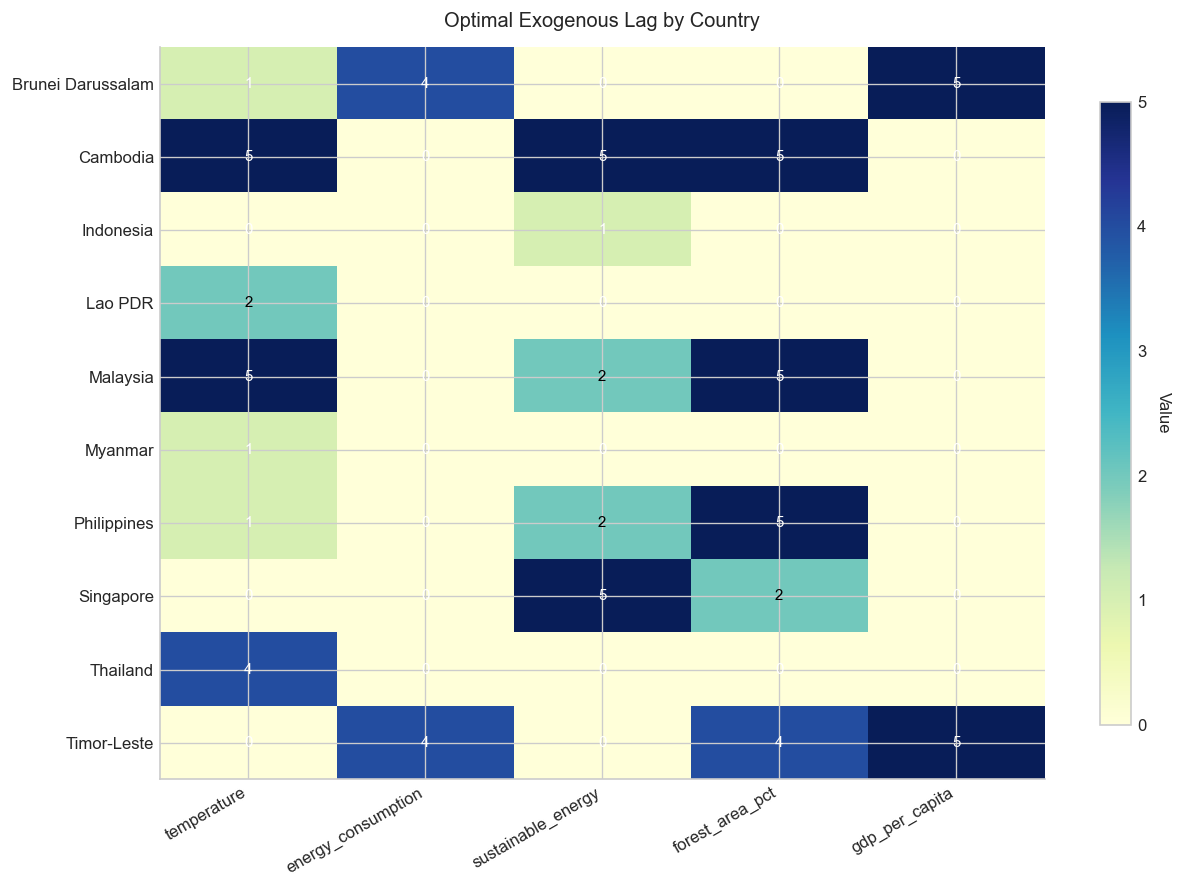

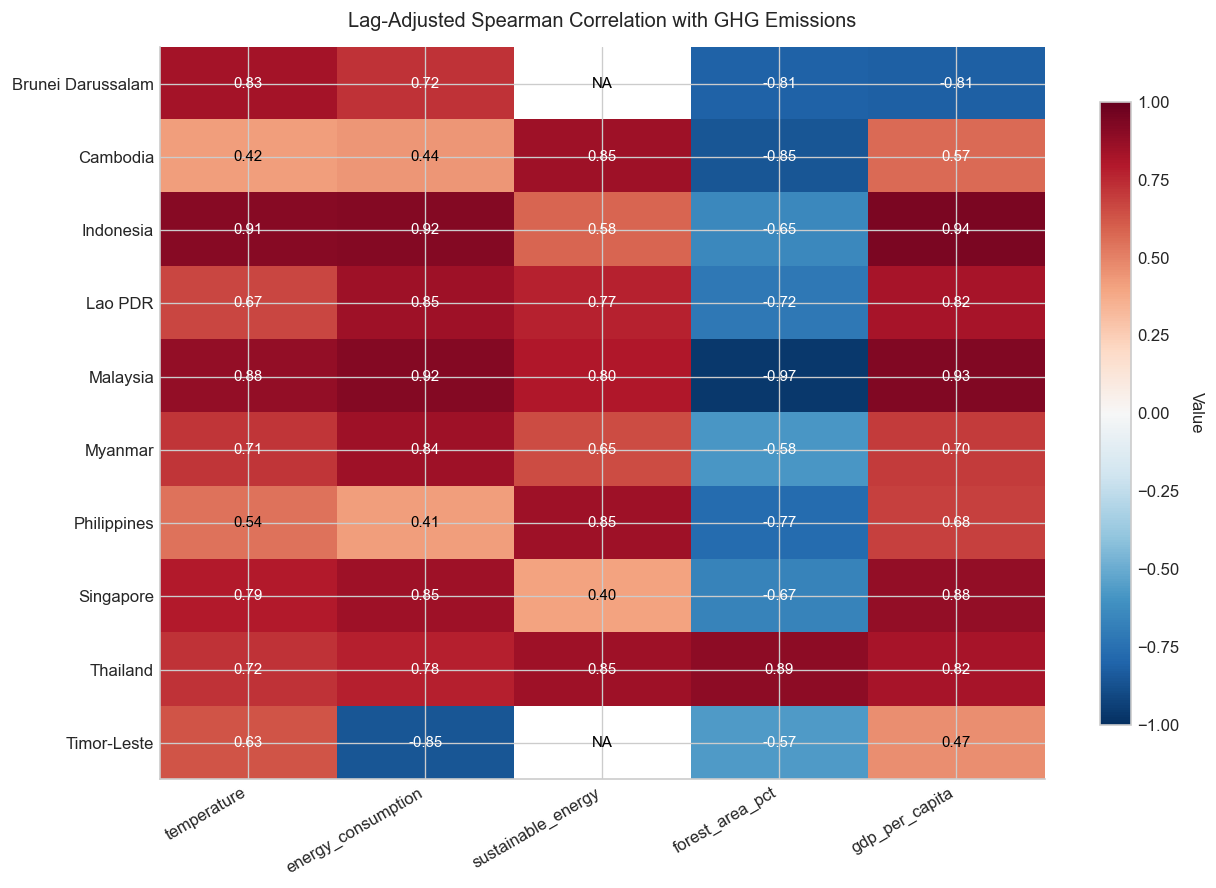

In [5]:
def plot_heatmap(frame: pd.DataFrame, title: str, cmap: str, value_fmt: str, vmin: float | None = None, vmax: float | None = None) -> None:
    plot_df = frame.copy()
    data = plot_df.to_numpy(dtype=float)
    if vmin is None:
        vmin = np.nanmin(data)
    if vmax is None:
        vmax = np.nanmax(data)

    fig_width = max(8, 1.35 * len(plot_df.columns) + 4)
    fig_height = max(5, 0.55 * len(plot_df.index) + 2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(plot_df.columns)), plot_df.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(plot_df.index)), plot_df.index)
    ax.set_title(title, pad=12)

    midpoint = (vmin + vmax) / 2 if vmin is not None and vmax is not None else 0.0
    spread = max((vmax - vmin) / 2, 1e-9) if vmin is not None and vmax is not None else 1.0
    for row_idx in range(plot_df.shape[0]):
        for col_idx in range(plot_df.shape[1]):
            value = data[row_idx, col_idx]
            label = "NA" if np.isnan(value) else format(value, value_fmt)
            text_color = "white" if np.isfinite(value) and abs(value - midpoint) > 0.55 * spread else "black"
            ax.text(col_idx, row_idx, label, ha="center", va="center", color=text_color, fontsize=9)

    cbar = plt.colorbar(image, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Value", rotation=270, labelpad=15)
    plt.tight_layout()
    if "agg" in plt.get_backend().lower():
        plt.close(fig)
    else:
        plt.show()


plot_heatmap(
    lag_summary_df.set_index("country")[EXOGENOUS_FEATURES],
    title="Optimal Exogenous Lag by Country",
    cmap="YlGnBu",
    value_fmt=".0f",
    vmin=0,
    vmax=MAX_EXOGENOUS_LAG,
)

plot_heatmap(
    country_feature_corr_df,
    title="Lag-Adjusted Spearman Correlation with GHG Emissions",
    cmap="RdBu_r",
    value_fmt=".2f",
    vmin=-1,
    vmax=1,
)


## Candidate models and validation logic

The notebook compares a small set of forecasting candidates:
- persistence baseline,
- recent-average baseline,
- short linear trend,
- ridge regression on delta,
- histogram gradient boosting on a log target.

The final model for each horizon is selected using rolling backtest RMSE, with MAE and a deterministic model ranking used as tie-breakers.


In [6]:
def fit_naive(_: pd.DataFrame, __: list[str]):
    return None


def predict_naive(_: object, feature_row: pd.DataFrame, __: pd.Series, ___: list[str], ____: int) -> float:
    return max(0.0, float(feature_row["ghg_current"].iloc[0]))


def fit_mean3(_: pd.DataFrame, __: list[str]):
    return None


def predict_mean3(_: object, __: pd.DataFrame, history: pd.Series, ___: list[str], ____: int) -> float:
    recent = history.dropna().tail(3)
    return np.nan if recent.empty else max(0.0, float(recent.mean()))


def fit_trend5(_: pd.DataFrame, __: list[str]):
    return None


def predict_trend5(_: object, __: pd.DataFrame, history: pd.Series, ___: list[str], horizon_years: int) -> float:
    observed = history.dropna().astype(float).sort_index().tail(5)
    if observed.empty:
        return np.nan
    if len(observed) == 1:
        return float(observed.iloc[-1])

    x = observed.index.to_numpy(dtype=float)
    y = observed.to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    forecast_year = float(x[-1] + horizon_years)
    return max(0.0, float(slope * forecast_year + intercept))


def fit_ridge_delta(train_df: pd.DataFrame, feature_cols: list[str]) -> Pipeline:
    model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    )
    model.fit(train_df[feature_cols], train_df["target_delta"])
    return model


def predict_ridge_delta(model: Pipeline, feature_row: pd.DataFrame, _: pd.Series, feature_cols: list[str], __: int) -> float:
    current = float(feature_row["ghg_current"].iloc[0])
    delta = float(model.predict(feature_row[feature_cols])[0])
    return max(0.0, current + delta)


def fit_histgb_log(train_df: pd.DataFrame, feature_cols: list[str]) -> Pipeline:
    model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                HistGradientBoostingRegressor(
                    learning_rate=0.05,
                    max_depth=3,
                    max_iter=300,
                    l2_regularization=0.1,
                    random_state=42,
                ),
            ),
        ]
    )
    target = np.log1p(np.clip(train_df["target_ghg"].to_numpy(dtype=float), 0.0, None))
    model.fit(train_df[feature_cols], target)
    return model


def predict_histgb_log(model: Pipeline, feature_row: pd.DataFrame, _: pd.Series, feature_cols: list[str], __: int) -> float:
    prediction = float(np.expm1(model.predict(feature_row[feature_cols])[0]))
    return max(0.0, prediction)


MODEL_CANDIDATES = [
    {
        "name": "naive",
        "family": "baseline_persistence",
        "fit": fit_naive,
        "predict": predict_naive,
    },
    {
        "name": "mean3",
        "family": "baseline_recent_average",
        "fit": fit_mean3,
        "predict": predict_mean3,
    },
    {
        "name": "trend5",
        "family": "baseline_recent_linear_trend",
        "fit": fit_trend5,
        "predict": predict_trend5,
    },
    {
        "name": "ridge_delta",
        "family": "regularized_linear_delta",
        "fit": fit_ridge_delta,
        "predict": predict_ridge_delta,
    },
    {
        "name": "histgb_log",
        "family": "boosted_tree_log_target",
        "fit": fit_histgb_log,
        "predict": predict_histgb_log,
    },
]

MODEL_LOOKUP = {spec["name"]: spec for spec in MODEL_CANDIDATES}
MODEL_RANK = {"naive": 0, "mean3": 1, "trend5": 2, "ridge_delta": 3, "histgb_log": 4}


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


def reliability_tier(rmse: float, naive_rmse: float) -> str:
    if pd.isna(rmse) or pd.isna(naive_rmse):
        return "low"
    if rmse <= naive_rmse * 0.95:
        return "high"
    if rmse <= naive_rmse * 1.05:
        return "medium"
    return "low"


def choose_best_candidate(metrics_df: pd.DataFrame) -> pd.Series:
    ranked = metrics_df.assign(model_rank=metrics_df["candidate_model"].map(MODEL_RANK).fillna(99))
    return ranked.sort_values(["rmse_mtco2e", "mae_mtco2e", "model_rank"]).iloc[0]


def build_backtest_history(train_df: pd.DataFrame, test_row: pd.DataFrame) -> pd.Series:
    history = pd.concat(
        [train_df[["year", "ghg_current"]], test_row[["year", "ghg_current"]]],
        ignore_index=True,
    )
    return history.drop_duplicates("year", keep="last").sort_values("year").set_index("year")["ghg_current"]


def run_rolling_backtest(panel: pd.DataFrame, feature_cols: list[str], country: str, horizon_years: int) -> pd.DataFrame:
    training_df = build_training_frame(panel, horizon_years).sort_values("year").reset_index(drop=True)
    available_splits = len(training_df) - MIN_TRAIN_SIZE
    if available_splits < 3:
        return pd.DataFrame()

    n_splits = min(MAX_BACKTEST_YEARS, available_splits)
    test_start = len(training_df) - n_splits
    metric_rows = []

    for spec in MODEL_CANDIDATES:
        predictions = []
        for test_idx in range(test_start, len(training_df)):
            train_slice = training_df.iloc[:test_idx].copy()
            test_row = training_df.iloc[[test_idx]].copy()
            history = build_backtest_history(train_slice, test_row)
            model = spec["fit"](train_slice, feature_cols)
            prediction = spec["predict"](model, test_row, history, feature_cols, horizon_years)
            predictions.append(
                {
                    "actual_ghg_mtco2e": float(test_row["target_ghg"].iloc[0]),
                    "predicted_ghg_mtco2e": float(prediction),
                }
            )

        prediction_df = pd.DataFrame(predictions)
        actual = prediction_df["actual_ghg_mtco2e"].to_numpy(dtype=float)
        predicted = prediction_df["predicted_ghg_mtco2e"].to_numpy(dtype=float)
        metric_rows.append(
            {
                "country": country,
                "forecast_horizon_years": horizon_years,
                "candidate_model": spec["name"],
                "candidate_family": spec["family"],
                "backtest_years": len(prediction_df),
                "rmse_mtco2e": float(np.sqrt(mean_squared_error(actual, predicted))),
                "mae_mtco2e": float(mean_absolute_error(actual, predicted)),
                "mape_pct": float(mape(actual, predicted)),
                "r2": float(r2_score(actual, predicted)) if len(prediction_df) > 1 else np.nan,
            }
        )

    return pd.DataFrame(metric_rows)


def forecast_country(country: str, panel: pd.DataFrame, feature_cols: list[str]) -> tuple[dict[str, object] | None, pd.DataFrame]:
    metrics_by_horizon: dict[int, pd.DataFrame] = {}
    for horizon_years in range(1, FORECAST_YEARS + 1):
        metrics_df = run_rolling_backtest(panel, feature_cols, country, horizon_years)
        if not metrics_df.empty:
            metrics_by_horizon[horizon_years] = metrics_df

    if 1 not in metrics_by_horizon:
        return None, pd.DataFrame()

    latest_feature_row = panel.sort_values("year").tail(1).copy()
    latest_observed_year = int(latest_feature_row["year"].iloc[0])
    history = panel.dropna(subset=["ghg_current"]).sort_values("year").set_index("year")["ghg_current"]

    one_year_metrics = metrics_by_horizon[1]
    best_one_year = choose_best_candidate(one_year_metrics)
    one_year_benchmark = one_year_metrics.loc[one_year_metrics["candidate_model"] == "naive"].iloc[0]
    one_year_rmse = float(best_one_year["rmse_mtco2e"])
    one_year_naive_rmse = float(one_year_benchmark["rmse_mtco2e"])

    evaluation_row = {
        "country": country,
        "selected_model": str(best_one_year["candidate_model"]),
        "selected_model_family": str(best_one_year["candidate_family"]),
        "backtest_years": int(best_one_year["backtest_years"]),
        "train_rows_full": int(len(build_training_frame(panel, 1))),
        "latest_observed_year": latest_observed_year,
        "forecast_horizon_years": 1,
        "rmse_mtco2e": one_year_rmse,
        "mae_mtco2e": float(best_one_year["mae_mtco2e"]),
        "mape_pct": float(best_one_year["mape_pct"]),
        "r2": float(best_one_year["r2"]),
        "benchmark_model": "naive",
        "benchmark_rmse_mtco2e": one_year_naive_rmse,
        "benchmark_mae_mtco2e": float(one_year_benchmark["mae_mtco2e"]),
        "rmse_improvement_vs_benchmark_mtco2e": one_year_naive_rmse - one_year_rmse,
        "rmse_improvement_vs_benchmark_pct": (
            (one_year_naive_rmse - one_year_rmse) / one_year_naive_rmse * 100.0 if one_year_naive_rmse != 0 else np.nan
        ),
        "reliability_tier": reliability_tier(one_year_rmse, one_year_naive_rmse),
        "validation_strategy": "rolling_one_step_backtest_with_model_selection",
    }

    forecast_rows = []
    for horizon_years, metrics_df in metrics_by_horizon.items():
        best_candidate = choose_best_candidate(metrics_df)
        benchmark_row = metrics_df.loc[metrics_df["candidate_model"] == "naive"].iloc[0]
        spec = MODEL_LOOKUP[str(best_candidate["candidate_model"])]
        training_df = build_training_frame(panel, horizon_years)
        fitted_model = spec["fit"](training_df, feature_cols)
        prediction = spec["predict"](fitted_model, latest_feature_row, history, feature_cols, horizon_years)
        previous_value = float(history.iloc[-1])
        yoy_change = prediction - previous_value

        forecast_rows.append(
            {
                "country": country,
                "latest_observed_year": latest_observed_year,
                "source_year": latest_observed_year,
                "predict_for_year": latest_observed_year + horizon_years,
                "forecast_horizon_years": horizon_years,
                "selected_model": spec["name"],
                "selected_model_family": spec["family"],
                "predicted_ghg_mtco2e": prediction,
                "previous_ghg_mtco2e": previous_value,
                "yoy_change_mtco2e": yoy_change,
                "yoy_change_pct": yoy_change / previous_value * 100.0 if previous_value != 0 else np.nan,
                "backtest_rmse_mtco2e": float(best_candidate["rmse_mtco2e"]),
                "benchmark_rmse_mtco2e": float(benchmark_row["rmse_mtco2e"]),
                "rmse_improvement_vs_benchmark_mtco2e": float(benchmark_row["rmse_mtco2e"] - best_candidate["rmse_mtco2e"]),
                "reliability_tier": reliability_tier(float(best_candidate["rmse_mtco2e"]), float(benchmark_row["rmse_mtco2e"])),
                "forecast_basis": "direct_horizon_model_selection",
            }
        )

    return evaluation_row, pd.DataFrame(forecast_rows)


## Run the full pipeline

This cell trains and evaluates each country independently, then writes the final outputs to the working directory.

To change the forecast horizon, update `FORECAST_YEARS` in the configuration cell and rerun the notebook.


In [7]:
def round_numeric(df: pd.DataFrame, digits: int = FLOAT_PRECISION) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    rounded = df.copy()
    numeric_cols = rounded.select_dtypes(include=["number"]).columns
    rounded[numeric_cols] = rounded[numeric_cols].round(digits)
    return rounded


evaluation_rows = []
forecast_frames = []

for country in COUNTRIES:
    panel = country_artifacts[country]["panel"]
    feature_cols = country_artifacts[country]["feature_cols"]
    evaluation_row, forecast_df = forecast_country(country, panel, feature_cols)
    if evaluation_row is not None:
        evaluation_rows.append(evaluation_row)
    if not forecast_df.empty:
        forecast_frames.append(forecast_df)

evaluation_df = pd.DataFrame(evaluation_rows)
if not evaluation_df.empty:
    evaluation_df = round_numeric(
        evaluation_df
        .sort_values(["forecast_horizon_years", "reliability_tier", "rmse_mtco2e", "country"])
        .reset_index(drop=True)
    )

multi_year_df = pd.concat(forecast_frames, ignore_index=True) if forecast_frames else pd.DataFrame()
if not multi_year_df.empty:
    multi_year_df = round_numeric(
        multi_year_df.sort_values(["country", "predict_for_year"]).reset_index(drop=True)
    )

forecast_file_name = f"country_ghg_forecast_{FORECAST_YEARS}_years.csv"
if not multi_year_df.empty:
    start_year = int(multi_year_df["predict_for_year"].min())
    end_year = int(multi_year_df["predict_for_year"].max())
    forecast_file_name = f"country_ghg_forecast_{start_year}_{end_year}.csv"

evaluation_df.to_csv("country_model_evaluation.csv", index=False)
multi_year_df.to_csv(forecast_file_name, index=False)

print(f"Saved country_model_evaluation.csv: {len(evaluation_df)} rows")
print(f"Saved {forecast_file_name}: {len(multi_year_df)} rows")

display(evaluation_df)
display(multi_year_df.head(20))


Saved country_model_evaluation.csv: 10 rows
Saved country_ghg_forecast_2024_2028.csv: 50 rows


,country,selected_model,selected_model_family,backtest_years,train_rows_full,latest_observed_year,forecast_horizon_years,rmse_mtco2e,mae_mtco2e,mape_pct,r2,benchmark_model,benchmark_rmse_mtco2e,benchmark_mae_mtco2e,rmse_improvement_vs_benchmark_mtco2e,rmse_improvement_vs_benchmark_pct,reliability_tier,validation_strategy
0,Timor-Leste,trend5,baseline_recent_linear_trend,6,73,2023,1,0.209,0.169,3.294,0.102,naive,0.276,0.239,0.067,24.225,high,rolling_one_step_backtest_with_model_selection
1,Singapore,mean3,baseline_recent_average,6,73,2023,1,1.589,1.329,2.369,-0.558,naive,2.108,1.845,0.520,24.650,high,rolling_one_step_backtest_with_model_selection
2,Indonesia,histgb_log,boosted_tree_log_target,6,73,2023,1,187.063,152.960,8.217,-0.494,naive,233.135,186.367,46.072,19.762,high,rolling_one_step_backtest_with_model_selection
3,Brunei Darussalam,naive,baseline_persistence,6,73,2023,1,0.368,0.313,1.828,0.125,naive,0.368,0.313,0.000,0.000,medium,rolling_one_step_backtest_with_model_selection
4,Cambodia,naive,baseline_persistence,6,73,2023,1,3.263,2.792,3.273,-0.257,naive,3.263,2.792,0.000,0.000,medium,rolling_one_step_backtest_with_model_selection
5,Lao PDR,naive,baseline_persistence,6,73,2023,1,3.601,2.846,5.519,-1.047,naive,3.601,2.846,0.000,0.000,medium,rolling_one_step_backtest_with_model_selection
6,Philippines,naive,baseline_persistence,6,73,2023,1,7.383,6.144,2.265,-0.096,naive,7.383,6.144,0.000,0.000,medium,rolling_one_step_backtest_with_model_selection
7,Thailand,trend5,baseline_recent_linear_trend,6,73,2023,1,8.546,7.022,1.642,0.369,naive,8.748,8.022,0.202,2.310,medium,rolling_one_step_backtest_with_model_selection
8,Malaysia,naive,baseline_persistence,6,73,2023,1,11.125,7.820,1.949,-0.499,naive,11.125,7.820,0.000,0.000,medium,rolling_one_step_backtest_with_model_selection
9,Myanmar,naive,baseline_persistence,6,73,2023,1,11.711,8.095,3.816,-3.085,naive,11.711,8.095,0.000,0.000,medium,rolling_one_step_backtest_with_model_selection


,country,latest_observed_year,source_year,predict_for_year,forecast_horizon_years,selected_model,selected_model_family,predicted_ghg_mtco2e,previous_ghg_mtco2e,yoy_change_mtco2e,yoy_change_pct,backtest_rmse_mtco2e,benchmark_rmse_mtco2e,rmse_improvement_vs_benchmark_mtco2e,reliability_tier,forecast_basis
0,Brunei Darussalam,2023,2023,2024,1,naive,baseline_persistence,17.137,17.137,0.000,0.000,0.368,0.368,0.000,medium,direct_horizon_model_selection
1,Brunei Darussalam,2023,2023,2025,2,naive,baseline_persistence,17.137,17.137,0.000,0.000,0.991,0.991,0.000,medium,direct_horizon_model_selection
2,Brunei Darussalam,2023,2023,2026,3,ridge_delta,regularized_linear_delta,18.523,17.137,1.386,8.090,1.454,1.522,0.068,medium,direct_horizon_model_selection
3,Brunei Darussalam,2023,2023,2027,4,ridge_delta,regularized_linear_delta,18.243,17.137,1.106,6.456,1.415,1.778,0.363,high,direct_horizon_model_selection
4,Brunei Darussalam,2023,2023,2028,5,ridge_delta,regularized_linear_delta,18.242,17.137,1.105,6.445,1.219,2.017,0.798,high,direct_horizon_model_selection
5,Cambodia,2023,2023,2024,1,naive,baseline_persistence,82.998,82.998,0.000,0.000,3.263,3.263,0.000,medium,direct_horizon_model_selection
6,Cambodia,2023,2023,2025,2,naive,baseline_persistence,82.998,82.998,0.000,0.000,3.636,3.636,0.000,medium,direct_horizon_model_selection
7,Cambodia,2023,2023,2026,3,naive,baseline_persistence,82.998,82.998,0.000,0.000,4.624,4.624,0.000,medium,direct_horizon_model_selection
8,Cambodia,2023,2023,2027,4,naive,baseline_persistence,82.998,82.998,0.000,0.000,5.471,5.471,0.000,medium,direct_horizon_model_selection
9,Cambodia,2023,2023,2028,5,naive,baseline_persistence,82.998,82.998,0.000,0.000,6.736,6.736,0.000,medium,direct_horizon_model_selection


## Forecast visualization

A strong forecasting notebook should make the final trajectory easy to inspect, not only easy to export.

The chart below shows recent observed history and the forecast path for each country.


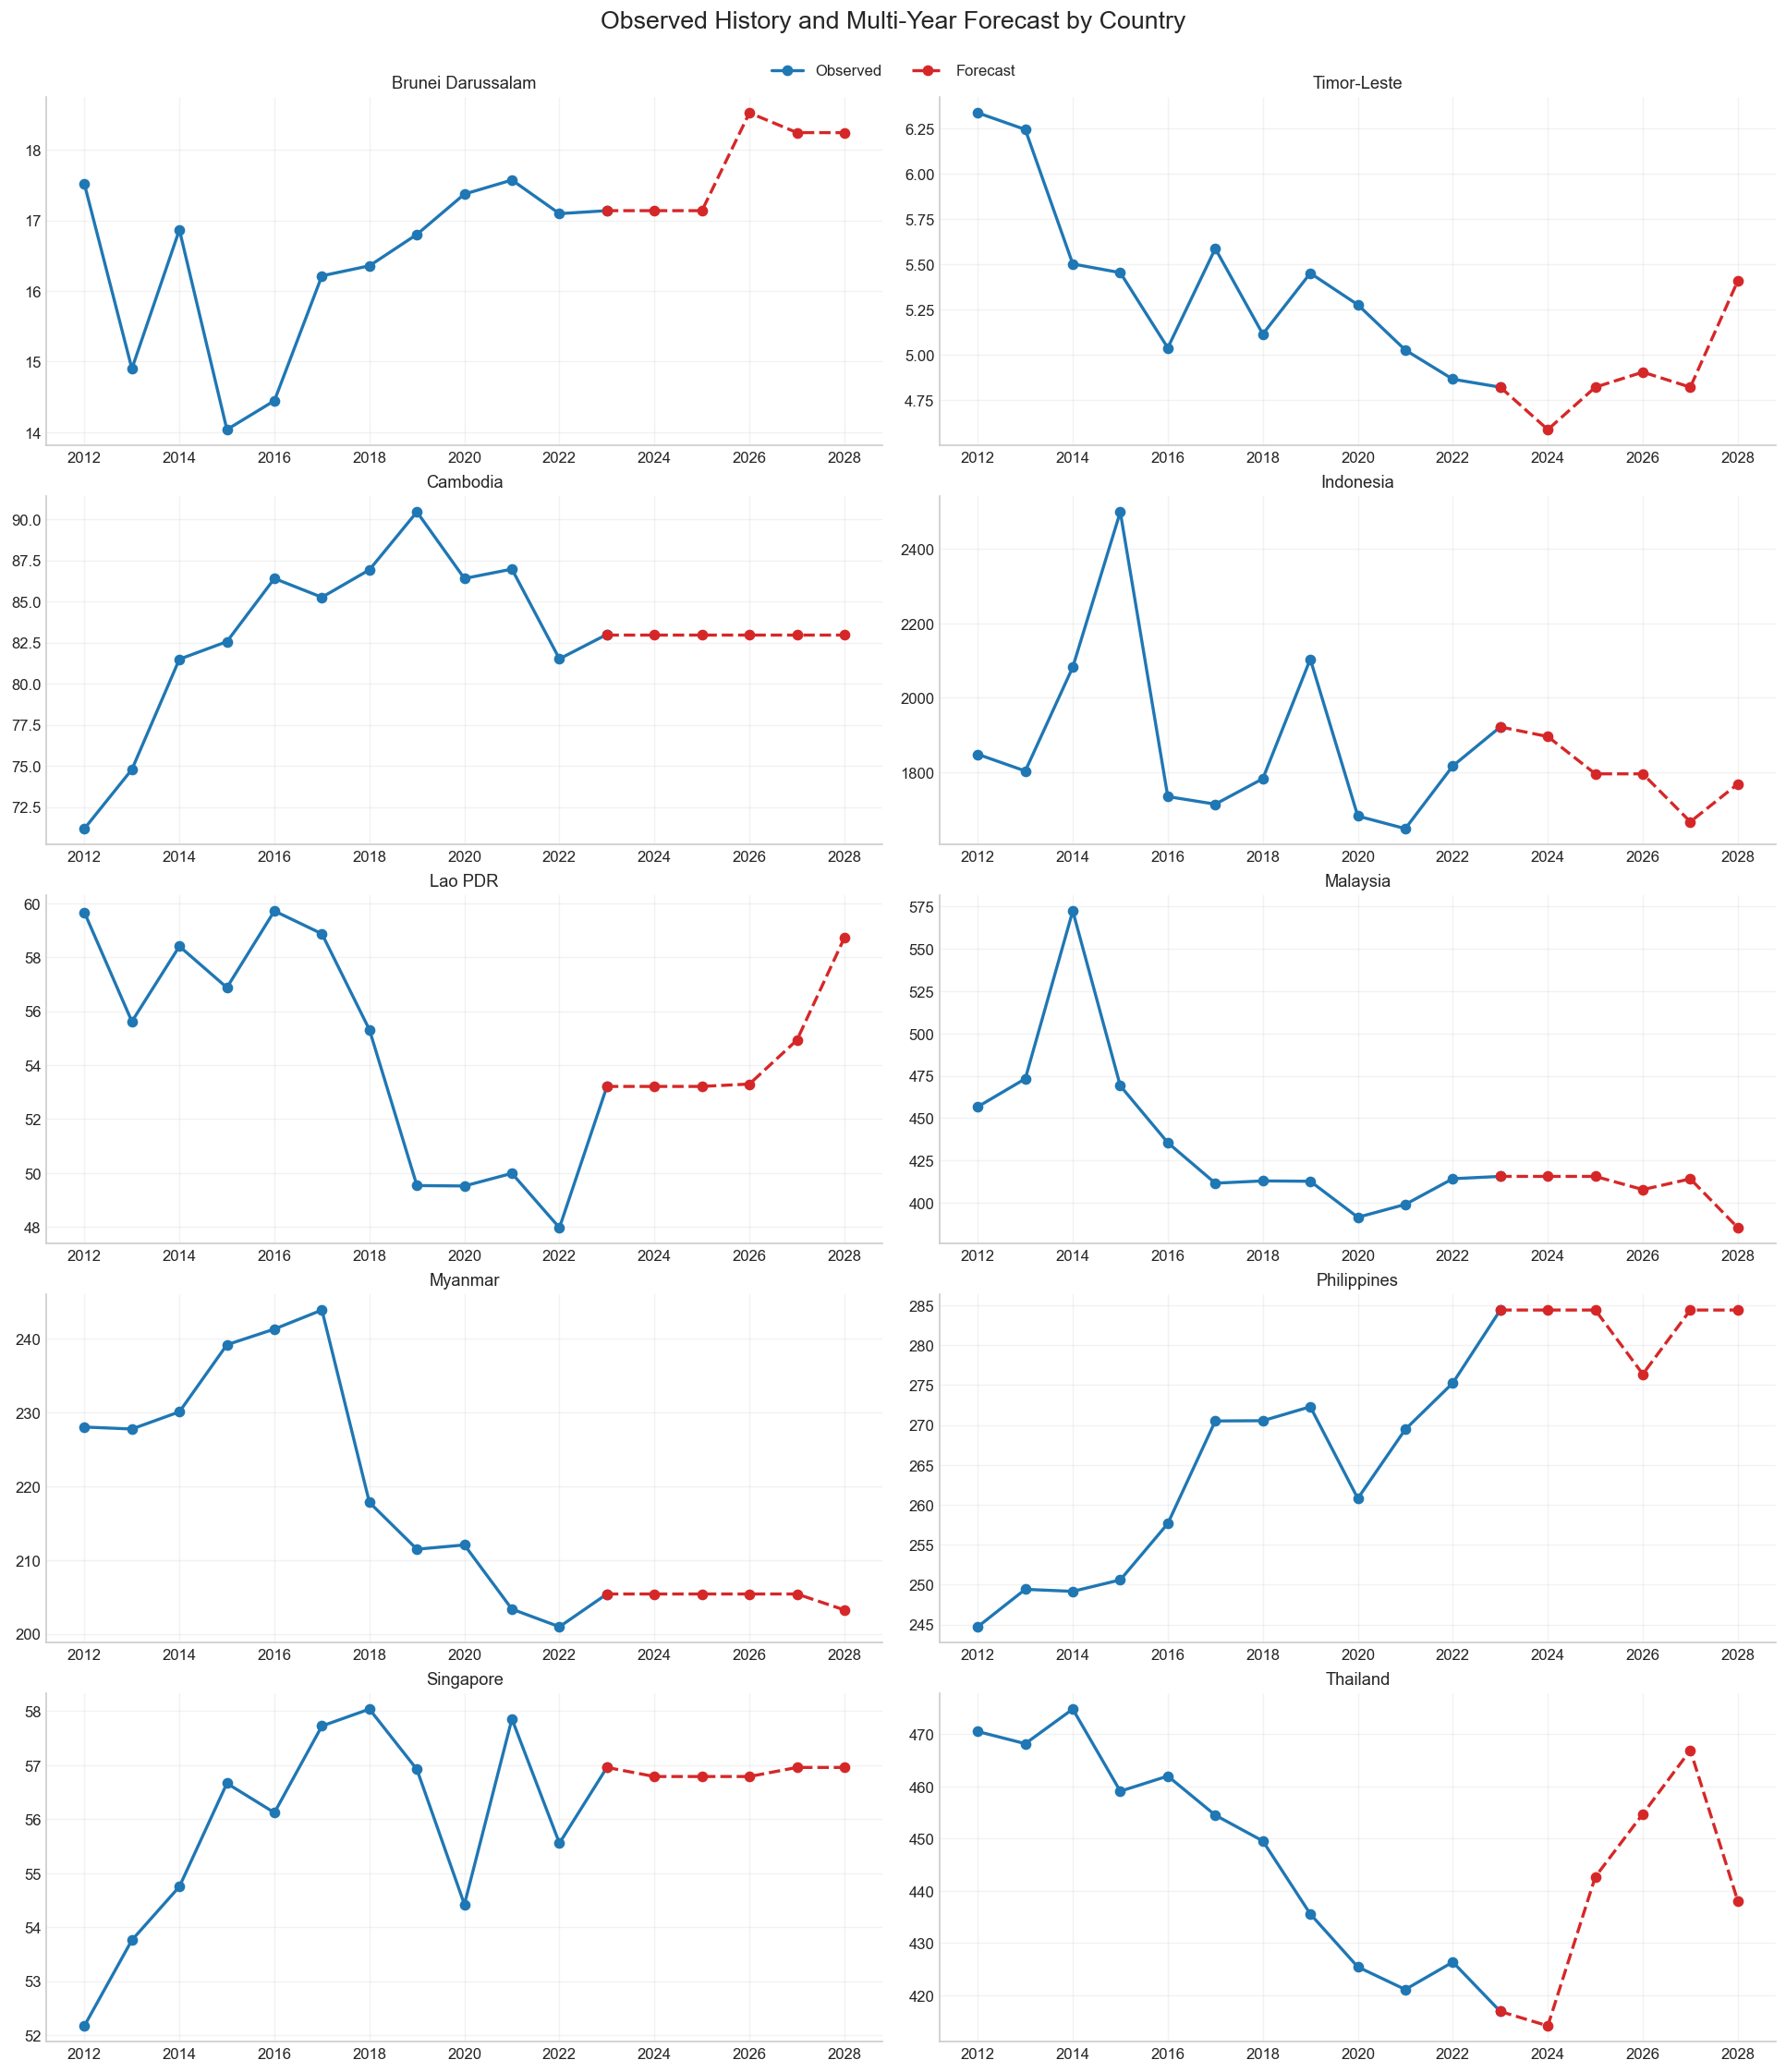

In [8]:
def plot_country_forecasts(country_artifacts: dict[str, dict[str, object]], forecast_df: pd.DataFrame, history_years: int = 12) -> None:
    fig, axes = plt.subplots(5, 2, figsize=(16, 18), constrained_layout=True)
    axes = axes.ravel()

    for ax, country in zip(axes, COUNTRIES):
        panel = country_artifacts[country]["panel"][["year", "ghg_current"]].dropna().copy()
        latest_year = int(panel["year"].max())
        history = panel.loc[panel["year"] >= latest_year - history_years + 1]

        ax.plot(history["year"], history["ghg_current"], marker="o", linewidth=2, label="Observed", color="#1f77b4")

        country_forecast = forecast_df.loc[forecast_df["country"] == country].sort_values("predict_for_year")
        if not country_forecast.empty:
            anchor_value = float(panel.loc[panel["year"] == latest_year, "ghg_current"].iloc[-1])
            forecast_years = [latest_year, *country_forecast["predict_for_year"].tolist()]
            forecast_values = [anchor_value, *country_forecast["predicted_ghg_mtco2e"].tolist()]
            ax.plot(forecast_years, forecast_values, marker="o", linestyle="--", linewidth=2, label="Forecast", color="#d62728")

        ax.set_title(country, fontsize=11)
        ax.ticklabel_format(style="plain", axis="y")
        ax.grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.01))
    fig.suptitle("Observed History and Multi-Year Forecast by Country", fontsize=16, y=1.03)
    if "agg" in plt.get_backend().lower():
        plt.close(fig)
    else:
        plt.show()


plot_country_forecasts(country_artifacts, multi_year_df)


## Final remarks

This notebook stays compact while adding the diagnostics that are worth the space:
- the parameter block is centralized,
- lag choices are visible instead of hidden inside helper functions,
- correlation structure is visualized in a country-level heatmap,
- the final forecast is shown as trajectories rather than only CSV rows.

That combination usually reads better on Kaggle than a long script export or a notebook full of low-value intermediate tables.
